In [1]:
import pandas as pd

# Data
df=pd.read_csv("/home/jolivera/Documents/CloudSkin/Time-Series-Library/dataset/comparison_of_approaches/check_per_exp_avg.csv", sep=";")

# cloud_cluster_only;0;0.0;0.0;0.0;0.0;0.0;91,764705882;0.0;0.0;28750.0;0.0;99.68


In [2]:
df

,approach,num_experiments,avg_num_steps,avg_overall_mean_latency,avg_peak_latency,avg_num_times_crossed_above_sla,avg_total_seconds_above_sla_edge_cluster,avg_total_seconds_above_sla_cloud_cluster,avg_number_migrations_edge_to_cloud,avg_number_migrations_cloud_to_edge,avg_total_seconds_in_cloud_cluster,avg_total_seconds_in_edge_cluster,avg_percent_time_below_sla
0,informer,2,953.500000,0.060666,0.615010,4.500000,825.0,0.0,2.00,1.000000,16680.0,12075.0,97.131287
1,random_forest,15,942.266667,0.063393,0.450828,1.933333,328.0,32.0,6.20,6.200000,18352.0,10402.0,98.747949
2,informer_30m,4,953.750000,0.065030,0.594809,7.750000,690.0,7.5,1.25,1.250000,23557.5,5182.5,97.572958
3,informer_filtered_SLAloss,2,954.000000,0.072233,0.636597,8.500000,1170.0,45.0,3.00,3.500000,15690.0,13050.0,95.772443
4,reactive,25,939.400000,0.073439,0.528360,6.200000,1088.4,157.2,3.36,3.160000,15956.4,12801.6,95.668618
5,multiple_linear_regression,3,951.000000,0.082383,0.599166,7.000000,1130.0,50.0,2.00,1.666667,17120.0,11640.0,95.896836
6,linear_regression,3,912.333333,0.164370,0.634490,24.666667,7620.0,460.0,22.00,22.000000,10130.0,18610.0,71.885873
7,cloud_cluster_only,0,0.000000,0.000000,0.000000,0.000000,0.0,"91,764705882",0.00,0.000000,28750.0,0.0,99.680000


In [3]:
df.iloc[7,10]=24*3600 # Setting Cloud only time to 24 hours

In [4]:
# Constants
aws_price_per_hour = 0.688*0.86
edge_energy_price = 0.137  # €/kWh
edge_high_power_kw = 0.182  # kW
edge_low_power_kw = 0.119  # kW

# Cost components
df["cloud_cost"] = (df["avg_total_seconds_in_cloud_cluster"] / 3600) * aws_price_per_hour
df["edge_cost"] = (df["avg_total_seconds_in_edge_cluster"] / 3600) * (edge_energy_price * edge_high_power_kw) + ((24*3600-(df["avg_total_seconds_in_edge_cluster"]+df["avg_total_seconds_in_cloud_cluster"]))/3600)*(edge_energy_price * edge_low_power_kw)
df["edge_to_cloud_migration_cost"] = (df["avg_number_migrations_edge_to_cloud"] * aws_price_per_hour)*180 / 3600
df["cloud_to_edge_migration_cost"] = (df["avg_number_migrations_cloud_to_edge"] * edge_energy_price * edge_high_power_kw)*30 / 3600

# Total cost
df["total_cost"] = df["cloud_cost"] + df["edge_cost"] + df["edge_to_cloud_migration_cost"] + df["cloud_to_edge_migration_cost"]

# Final columns
df_final_daily = df[
    [
        "approach",
        "avg_percent_time_below_sla",
        "total_cost",
        "cloud_cost",
        "edge_cost",
        "avg_number_migrations_edge_to_cloud",
        "edge_to_cloud_migration_cost",
        "avg_number_migrations_cloud_to_edge",
        "cloud_to_edge_migration_cost"

    ]
]


# Option 1: 
They already have infrastructure, we just add the main computing instance.

In [5]:
df_final_daily

,approach,avg_percent_time_below_sla,total_cost,cloud_cost,edge_cost,avg_number_migrations_edge_to_cloud,edge_to_cloud_migration_cost,avg_number_migrations_cloud_to_edge,cloud_to_edge_migration_cost
0,informer,97.131287,3.145511,2.741451,0.344685,2.00,0.059168,1.000000,0.000208
1,random_forest,98.747949,3.534064,3.016253,0.333102,6.20,0.183421,6.200000,0.001288
2,informer_30m,97.572958,4.206060,3.871806,0.297014,1.25,0.036980,1.250000,0.000260
3,informer_filtered_SLAloss,95.772443,3.019723,2.578739,0.351505,3.00,0.088752,3.500000,0.000727
4,reactive,95.668618,3.072285,2.622523,0.349704,3.36,0.099402,3.160000,0.000657
5,multiple_linear_regression,95.896836,3.214930,2.813767,0.341649,2.00,0.059168,1.666667,0.000346
6,linear_regression,71.885873,2.710356,1.664922,0.390015,22.00,0.650848,22.000000,0.004571
7,cloud_cluster_only,99.680000,14.200320,14.200320,0.000000,0.00,0.000000,0.000000,0.000000


# Option 2:
We deploy everything.

In [6]:
ebs_cost= 0.088*0.86/30 # €/GB-month. Includes 3000 IOPS and 125 MB/s of throughput.
storage_needed= 100 # GB
control_plane_instance_cost= 0.0736*0.86*24 # t4g.large €/month

df["baseline_cost"] = ebs_cost*storage_needed + (control_plane_instance_cost)

df["total_cost"] = df["baseline_cost"] + df["cloud_cost"] + df["edge_cost"] + df["edge_to_cloud_migration_cost"] + df["cloud_to_edge_migration_cost"]


# Final columns
df_deployment_daily = df[
    [
        "approach",
        "avg_percent_time_below_sla",
        "total_cost",
        "baseline_cost",
        "cloud_cost",
        "edge_cost",
        "avg_number_migrations_edge_to_cloud",
        "edge_to_cloud_migration_cost",
        "avg_number_migrations_cloud_to_edge",
        "cloud_to_edge_migration_cost"

    ]
]


In [7]:
df_deployment_daily

,approach,avg_percent_time_below_sla,total_cost,baseline_cost,cloud_cost,edge_cost,avg_number_migrations_edge_to_cloud,edge_to_cloud_migration_cost,avg_number_migrations_cloud_to_edge,cloud_to_edge_migration_cost
0,informer,97.131287,4.916882,1.771371,2.741451,0.344685,2.00,0.059168,1.000000,0.000208
1,random_forest,98.747949,5.305435,1.771371,3.016253,0.333102,6.20,0.183421,6.200000,0.001288
2,informer_30m,97.572958,5.977431,1.771371,3.871806,0.297014,1.25,0.036980,1.250000,0.000260
3,informer_filtered_SLAloss,95.772443,4.791094,1.771371,2.578739,0.351505,3.00,0.088752,3.500000,0.000727
4,reactive,95.668618,4.843656,1.771371,2.622523,0.349704,3.36,0.099402,3.160000,0.000657
5,multiple_linear_regression,95.896836,4.986301,1.771371,2.813767,0.341649,2.00,0.059168,1.666667,0.000346
6,linear_regression,71.885873,4.481726,1.771371,1.664922,0.390015,22.00,0.650848,22.000000,0.004571
7,cloud_cluster_only,99.680000,15.971691,1.771371,14.200320,0.000000,0.00,0.000000,0.000000,0.000000


In [8]:
df_deployment_daily[df_deployment_daily["approach"].isin(["cloud_cluster_only","reactive","random_forest"])]






,approach,avg_percent_time_below_sla,total_cost,baseline_cost,cloud_cost,edge_cost,avg_number_migrations_edge_to_cloud,edge_to_cloud_migration_cost,avg_number_migrations_cloud_to_edge,cloud_to_edge_migration_cost
1,random_forest,98.747949,5.305435,1.771371,3.016253,0.333102,6.20,0.183421,6.20,0.001288
4,reactive,95.668618,4.843656,1.771371,2.622523,0.349704,3.36,0.099402,3.16,0.000657
7,cloud_cluster_only,99.680000,15.971691,1.771371,14.200320,0.000000,0.00,0.000000,0.00,0.000000


## Exponential impact

In [73]:
import math
import matplotlib.pyplot as plt
import pandas as pd
df1=pd.read_csv("/home/jolivera/Documents/CloudSkin/Time-Series-Library/f2f_meeting/comparison_of_approaches/reactive/job-0/preprocessed/inference_data_eb0e3eaa_b668_4ad6_bc10_2bb0eb7da259_20250923_101748.csv", sep=",")
df2=pd.read_csv("/home/jolivera/Documents/CloudSkin/Time-Series-Library/f2f_meeting/comparison_of_approaches/reactive/job-0/preprocessed/inference_data_fd7816db_7948_4602_af7a_1d51900792a7_20250923_101748.csv", sep=",")
df=pd.concat([df1,df2]).sort_values(by="date")
start_time=1757865859.050266
end_time=1757894661.13517
df.date=pd.to_datetime(df.date)
df=df[df['date']>=pd.to_datetime(start_time,unit="s")]
df=df[df['date']<=pd.to_datetime(end_time,unit="s")].reset_index(drop=True)


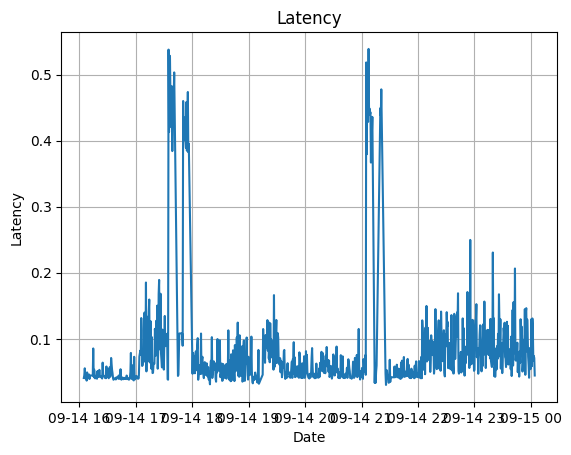

In [74]:
plt.plot(df['date'], df['pipelines_status_realtime_pipeline_latency'])
plt.xlabel('Date')
plt.ylabel('Latency')
plt.title('Latency')
plt.grid(True)


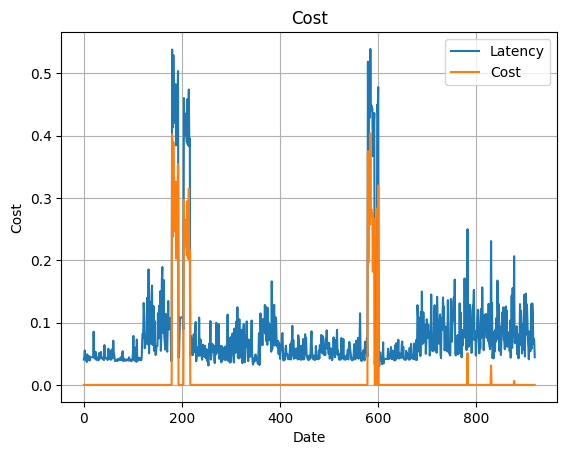

In [83]:
alpha=1
beta=1
costs=[]
for x in range(len(df)):
    if df["pipelines_status_realtime_pipeline_latency"][x]>=0.200:
        costs.append(alpha*(math.exp(beta*(df["pipelines_status_realtime_pipeline_latency"][x]-0.200))-1))
    else:
        costs.append(0)
df["cost"]=costs
plt.plot(df.index, df["pipelines_status_realtime_pipeline_latency"], df['cost'])
plt.xlabel('Date')
plt.ylabel('Cost')
plt.title('Cost')
plt.legend(["Latency", "Cost"])
plt.grid(True)

In [79]:
df[df["cost"]>0].cost

180    0.402003
181    0.237343
182    0.389381
183    0.388335
184    0.304876
185    0.301914
186    0.246283
187    0.326280
188    0.202333
189    0.270905
190    0.306477
191    0.306324
192    0.354394
204    0.297033
205    0.221988
206    0.240784
207    0.265020
208    0.226309
209    0.221596
210    0.208027
211    0.294973
212    0.202935
213    0.258670
214    0.314835
215    0.200246
216    0.215697
579    0.375000
580    0.196476
581    0.315233
582    0.261217
583    0.256683
584    0.403446
585    0.270304
586    0.282309
587    0.271168
588    0.275062
589    0.181589
590    0.266240
591    0.235391
592    0.266094
598    0.283175
599    0.268554
600    0.320086
782    0.050968
830    0.031122
877    0.006464
Name: cost, dtype: float64

In [82]:
df[df["cost"]>0].cost

180    28.342001
181     7.412002
182    25.804855
183    25.603761
184    13.311741
185    12.990218
186     8.039955
187    15.840428
188     5.313179
189     9.993400
190    13.488310
191    13.471385
192    19.770646
204    12.474469
205     6.424545
206     7.648938
207     9.494830
208     6.691314
209     6.400730
210     5.618583
211    12.261949
212     5.344863
213     8.979737
214    14.442359
215     5.204447
216     6.051030
579    23.156077
580     5.012291
581    14.489160
582     9.183554
583     8.823285
584    28.645299
585     9.941476
586    11.020583
587    10.016174
588    10.358282
589     4.304763
590     9.596450
591     7.280290
592     9.584255
598    11.102021
599     9.791717
600    15.070209
782     0.643969
830     0.358622
877     0.066551
Name: cost, dtype: float64

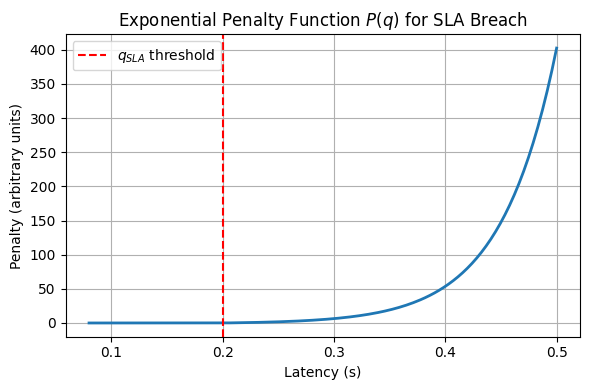

In [103]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters (illustrative only)
alpha = 1
beta = 20
q_sla = 0.200  # s

# Range of latencies
q = np.linspace(80, 500, 200)/1000
P = np.where(q > q_sla, alpha * (np.exp(beta * (q - q_sla)) - 1), 0)

plt.figure(figsize=(6,4))
plt.plot(q, P, linewidth=2)
plt.axvline(q_sla, color='r', linestyle='--', label=r'$q_{SLA}$ threshold')
plt.title("Exponential Penalty Function $P(q)$ for SLA Breach")
plt.xlabel("Latency (s)")
plt.ylabel("Penalty (arbitrary units)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
